In [2]:
import pandas as pd

# Add encoding parameter to handle non-UTF-8 characters
# Common encodings to try: 'latin1', 'ISO-8859-1', 'cp1252'
df = pd.read_csv("C:/Users/Lenovo/Downloads/Sample_Superstore.csv", encoding='latin1')

# Alternative encodings if 'latin1' doesn't work:
# df = pd.read_csv("C:/Users/Lenovo/Downloads/Sample_Superstore.csv", encoding='ISO-8859-1')
# df = pd.read_csv("C:/Users/Lenovo/Downloads/Sample_Superstore.csv", encoding='cp1252')

# You can also try with error handling:
# df = pd.read_csv("C:/Users/Lenovo/Downloads/Sample_Superstore.csv", encoding='utf-8', errors='replace')

df.head()  # View first 5 rows
df.info()  # Check column types
df.describe()  # Quick stats

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
df.dropna(inplace=True)  # Drop missing values
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month_name()
df['Year'] = df['Order Date'].dt.year


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [16]:
df = pd.read_csv('C:/Users/Lenovo/Downloads/Sample_Superstore.csv',encoding= 'ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


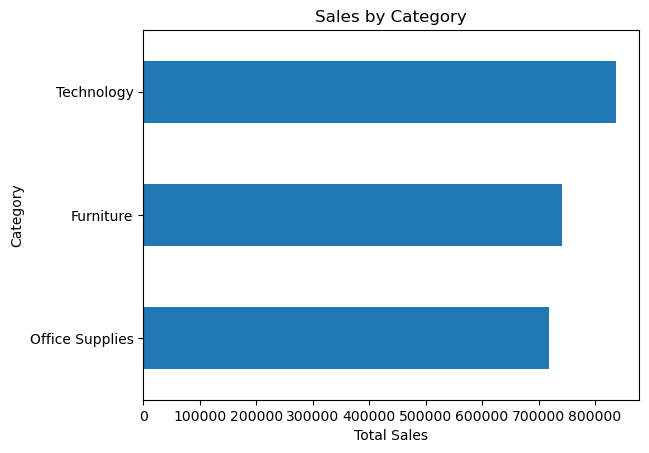

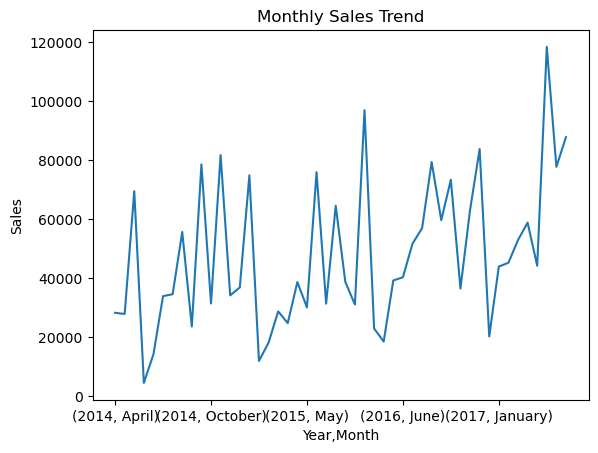

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
category_sales.plot(kind='barh', title='Sales by Category')
plt.xlabel('Total Sales')
plt.ylabel('Category')
plt.show()

# Sales over Time
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum()
monthly_sales.plot(kind='line', title='Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()


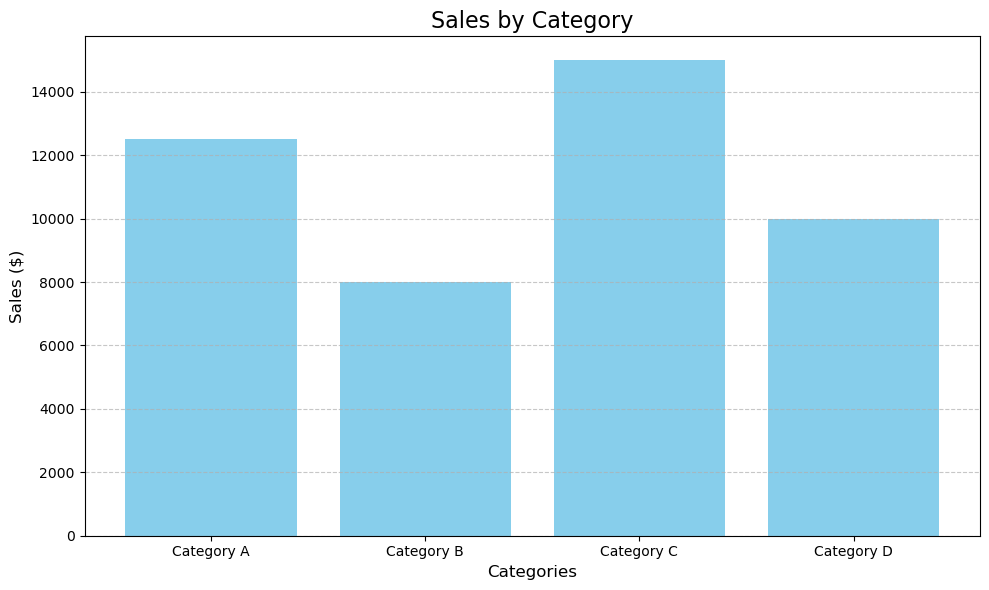

Figure saved successfully in C:\Users\Lenovo\visuals\sales_by_category.png


In [8]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Create sample data for demonstration
categories = ['Category A', 'Category B', 'Category C', 'Category D']
sales = [12500, 8000, 15000, 10000]

# Create the directory for saving
os.makedirs('visuals', exist_ok=True)

# Create the plot
plt.figure(figsize=(10, 6))  # Set figure size
plt.bar(categories, sales, color='skyblue')
plt.title('Sales by Category', fontsize=16)
plt.xlabel('Categories', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Make sure to save AFTER creating the plot
plt.tight_layout()  # Adjust layout to make room for labels
plt.savefig('visuals/sales_by_category.png', dpi=300)  # Higher DPI for better quality

# Optional: Display the plot in the notebook
plt.show()

print(f"Figure saved successfully in {os.path.abspath('visuals/sales_by_category.png')}")

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


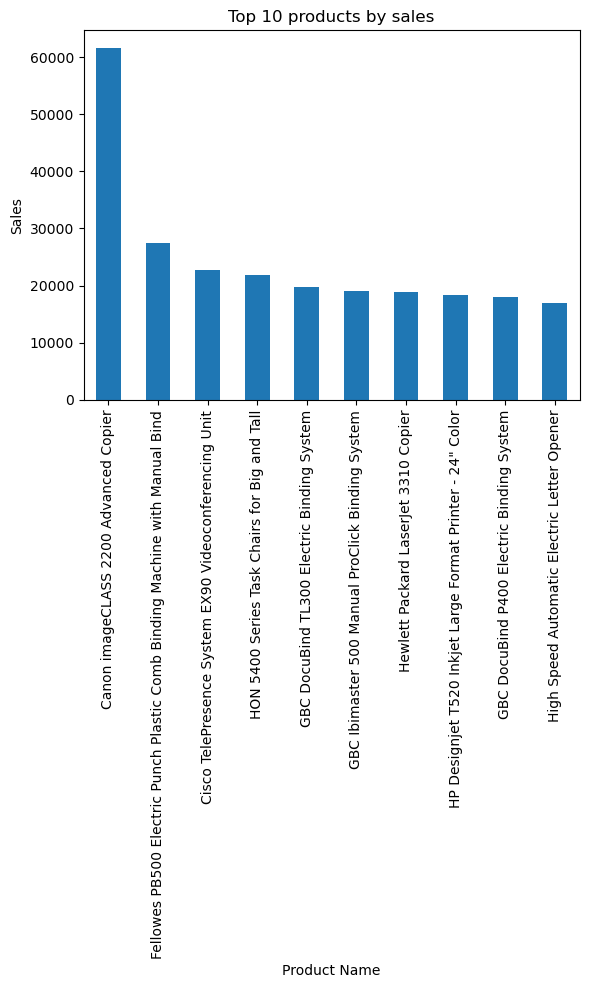

In [22]:
# Top 10 products by sales
# First, check the actual column names in your DataFrame
# Assuming the sales column might be named 'Sales' (capitalized) or something similar
print(df.columns)  # Uncomment this line to see all column names

# Then use the correct column name in your groupby operation
# Adjust 'Product Name' and 'Sales' to match your actual column names
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar', title='Top 10 products by sales')
plt.ylabel('Sales')
plt.show()

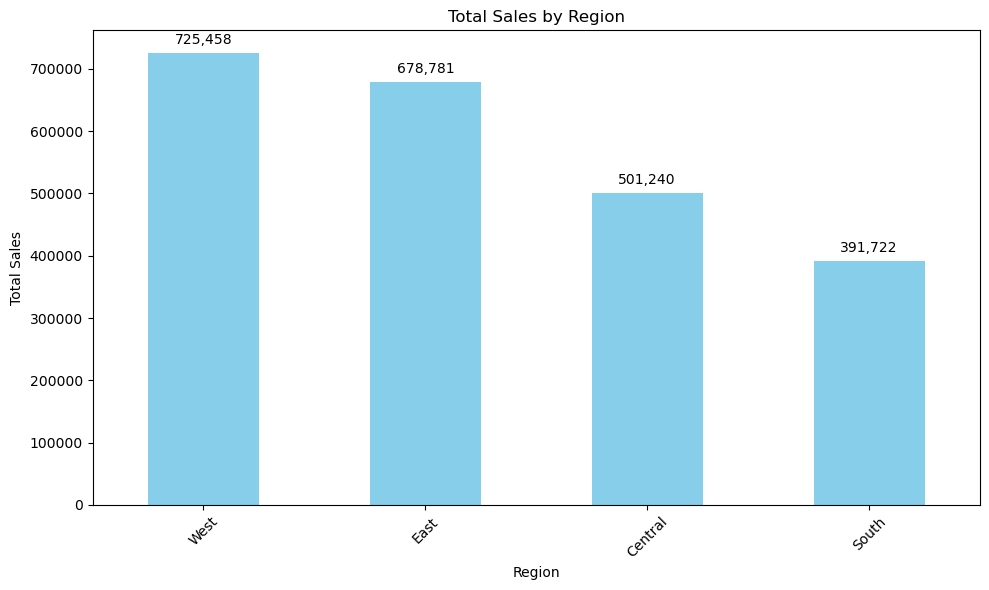

Sales by Region:
Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [24]:
# Sales by region analysis
# Make sure to import necessary libraries if not already imported
# import pandas as pd
# import matplotlib.pyplot as plt

# Group by Region and sum the Sales
# Adjust 'Region' and 'Sales' to match your actual column names
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# Create a bar chart
plt.figure(figsize=(10, 6))
sales_by_region.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

# Add data labels on top of each bar
for i, value in enumerate(sales_by_region.values):
    plt.text(i, value + (max(sales_by_region.values) * 0.02), # Slight offset above bar
             f'{value:,.0f}',  # Format with commas and no decimal places
             ha='center')

plt.show()

# Optional: Display the numerical results as well
print("Sales by Region:")
print(sales_by_region)

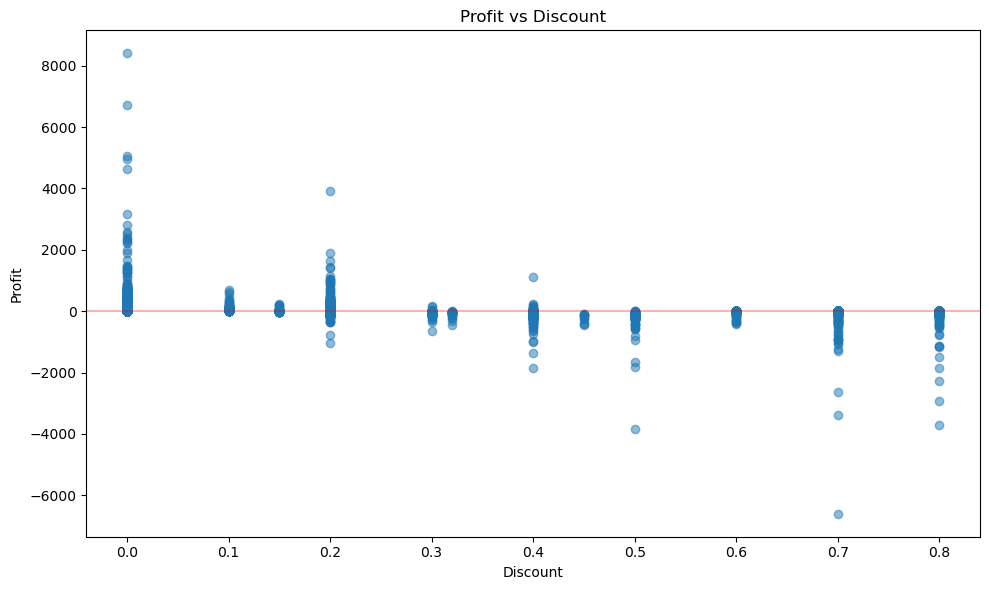

Correlation between Discount and Profit: -0.2195

Average Profit by Discount Level:
    Discount_Group        mean  count
0             0.00   66.900292   4798
1             0.10   96.055074     94
2             0.15   27.288298     52
3             0.20   24.702572   3657
4             0.30  -50.237855    254
5             0.40 -111.927429    206
6             0.45 -226.646464     11
7             0.50 -310.703456     66
8             0.60  -43.077212    138
9             0.70  -95.874060    418
10            0.80 -101.796797    300


In [26]:
# Analysis of Profit vs Discount relationship
# Make sure to import necessary libraries if not already imported
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))

# Option 1: Simple scatter plot
# Adjust 'Discount' and 'Profit' to match your actual column names
plt.scatter(df['Discount'], df['Profit'], alpha=0.5)
plt.title('Profit vs Discount')
plt.xlabel('Discount')
plt.ylabel('Profit')

# Add a horizontal line at Profit = 0 to highlight profit/loss threshold
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)

# Option 2: Add a trend line (uncomment to use)
# sns.regplot(x='Discount', y='Profit', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.tight_layout()
plt.show()

# Optional: Calculate correlation between Discount and Profit
correlation = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Profit: {correlation:.4f}")

# Optional: Group by discount ranges to see average profit at different discount levels
# Round discounts to nearest 0.05 (5%) for grouping
df['Discount_Group'] = (df['Discount'] * 20).round() / 20
discount_analysis = df.groupby('Discount_Group')['Profit'].agg(['mean', 'count']).reset_index()
print("\nAverage Profit by Discount Level:")
print(discount_analysis.sort_values('Discount_Group'))

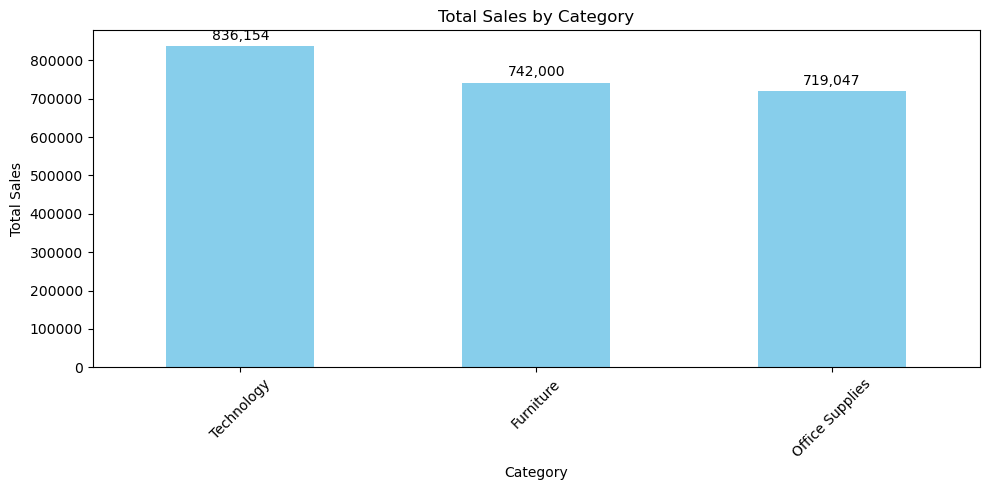

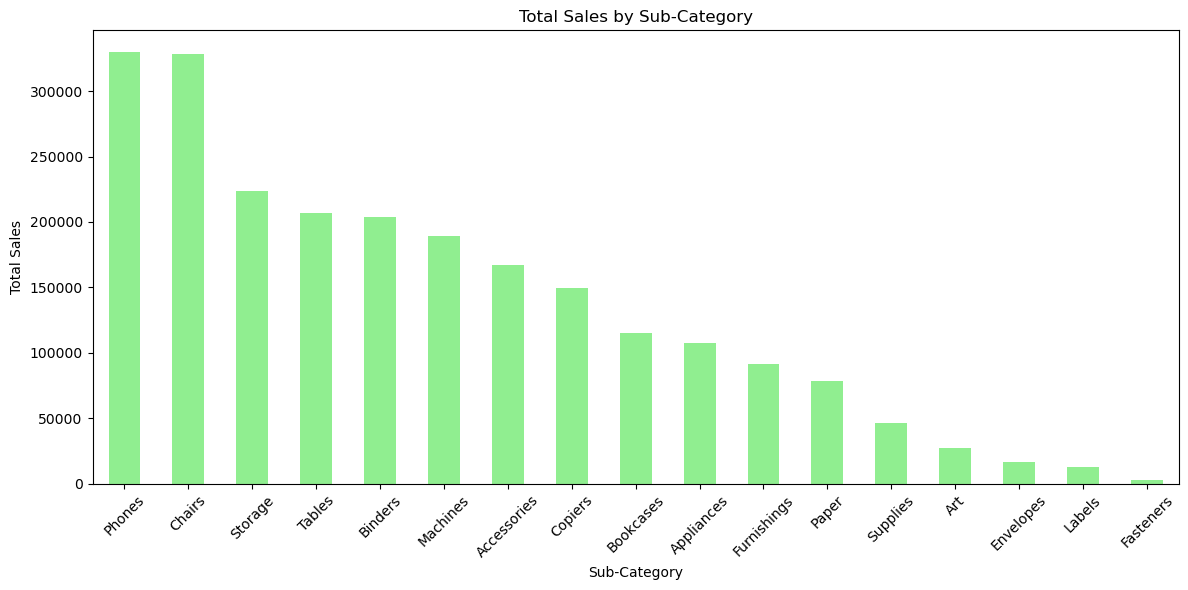

<Figure size 1400x800 with 0 Axes>

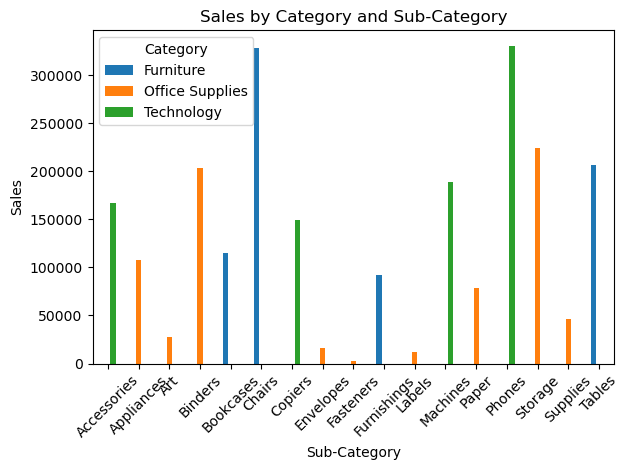

Sales by Category:
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Sales by Sub-Category:
Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


In [28]:
# Sales by Category and Sub-Category
# Make sure to import necessary libraries if not already imported
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# Part 1: Sales by Category
plt.figure(figsize=(10, 5))
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sales_by_category.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

# Add data labels on top of each bar
for i, value in enumerate(sales_by_category.values):
    plt.text(i, value + (max(sales_by_category.values) * 0.02),
             f'{value:,.0f}',
             ha='center')

plt.tight_layout()
plt.show()

# Part 2: Sales by Sub-Category
plt.figure(figsize=(12, 6))
sales_by_subcategory = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
sales_by_subcategory.plot(kind='bar', color='lightgreen')
plt.title('Total Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

# Add data labels on top of each bar (optional for many sub-categories)
if len(sales_by_subcategory) <= 15:  # Only add labels if there aren't too many bars
    for i, value in enumerate(sales_by_subcategory.values):
        plt.text(i, value + (max(sales_by_subcategory.values) * 0.02),
                 f'{value:,.0f}',
                 ha='center')

plt.tight_layout()
plt.show()

# Part 3: Hierarchical view - Sales by Category and Sub-Category
plt.figure(figsize=(14, 8))
category_subcategory = df.pivot_table(
    values='Sales',
    index='Sub-Category',
    columns='Category',
    aggfunc='sum',
    fill_value=0
)

category_subcategory.plot(kind='bar', stacked=False)
plt.title('Sales by Category and Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')
plt.legend(title='Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print the numerical results
print("Sales by Category:")
print(sales_by_category)
print("\nSales by Sub-Category:")
print(sales_by_subcategory)

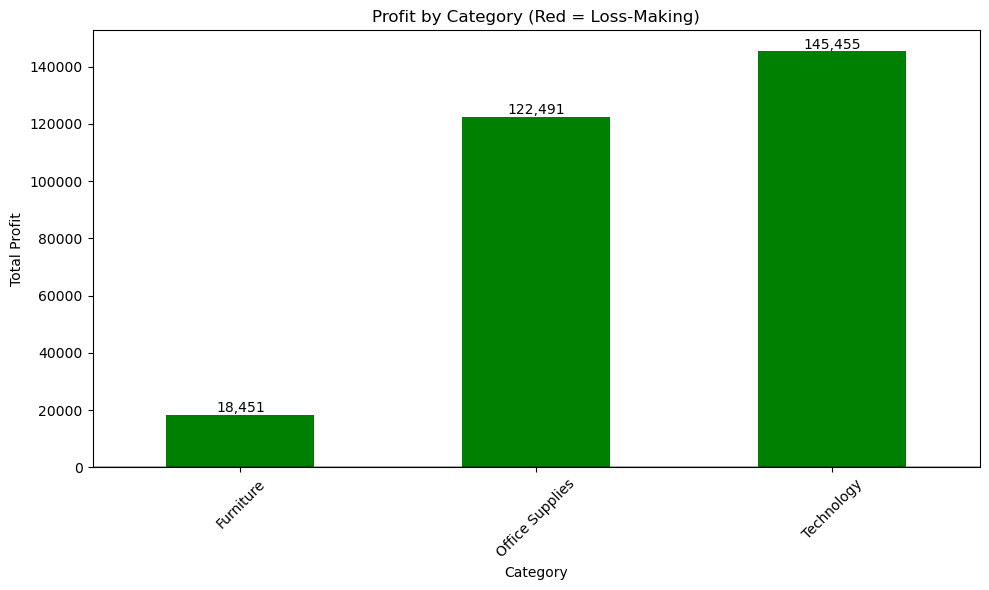

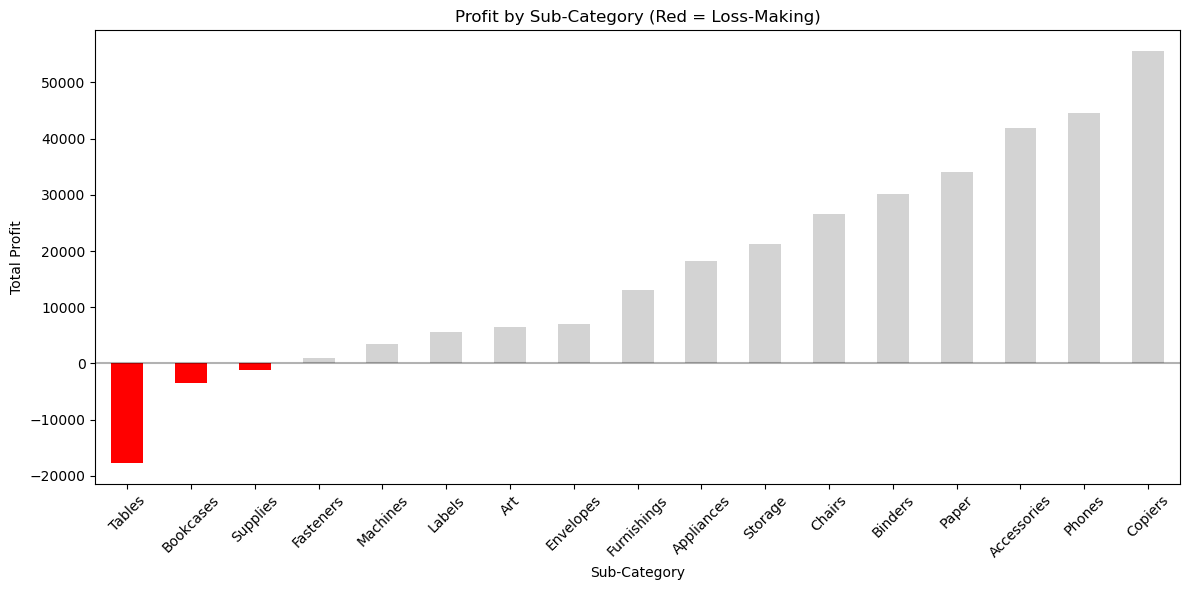

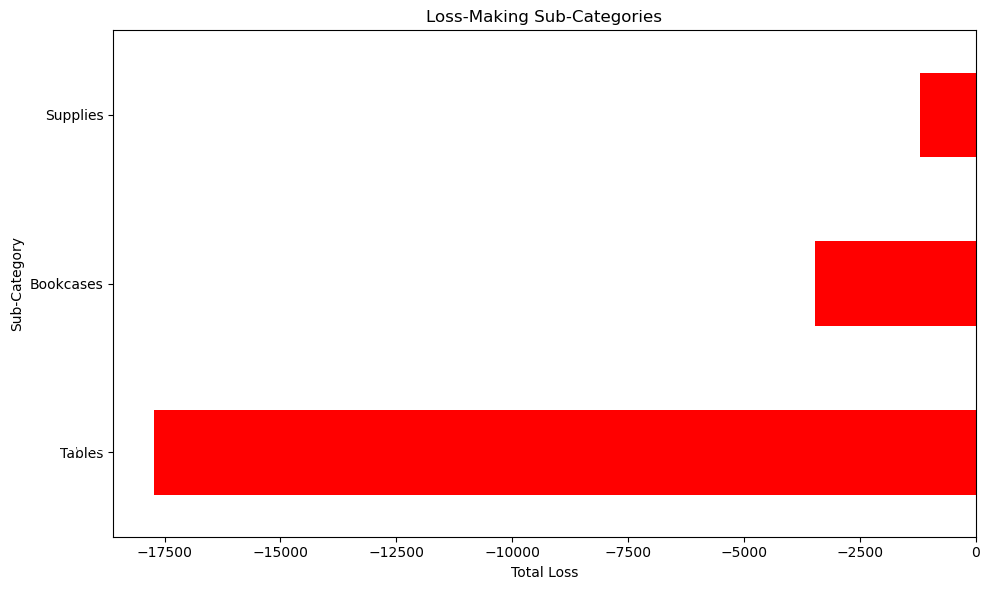

Top 10 Products with Highest Losses:
Category         Sub-Category  Product Name                                                               
Technology       Machines      Cubify CubeX 3D Printer Double Head Print                                     -9239.9692
Office Supplies  Binders       GBC DocuBind P400 Electric Binding System                                     -6859.3896
Technology       Machines      Lexmark MX611dhe Monochrome Laser Printer                                     -5269.9690
Office Supplies  Binders       GBC Ibimaster 500 Manual ProClick Binding System                              -5098.5660
                               GBC DocuBind TL300 Electric Binding System                                    -4162.0336
Technology       Machines      Cubify CubeX 3D Printer Triple Head Print                                     -3839.9904
Office Supplies  Binders       Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind   -3431.6730
Furniture       

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6588\3180108639.py:79: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category_loss_percent = df.groupby('Category').apply(


In [30]:
# Analysis of Loss-Making Categories
# Make sure to import necessary libraries if not already imported
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# Part 1: Identify loss-making categories
category_profit = df.groupby('Category')['Profit'].sum().sort_values()
loss_making_categories = category_profit[category_profit < 0]

# Part 2: Identify loss-making sub-categories
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
loss_making_subcategories = subcategory_profit[subcategory_profit < 0]

# Visualization 1: Profit by Category (highlighting losses)
plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in category_profit]
category_profit.plot(kind='bar', color=colors)
plt.title('Profit by Category (Red = Loss-Making)')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xticks(rotation=45)

# Add data labels
for i, value in enumerate(category_profit):
    color = 'red' if value < 0 else 'black'
    plt.text(i, value + (abs(min(category_profit)) * 0.05) * (1 if value >= 0 else -1), 
             f'{value:,.0f}',
             ha='center', color=color)

plt.tight_layout()
plt.show()

# Visualization 2: Profit by Sub-Category (focusing on losses)
plt.figure(figsize=(12, 6))
colors = ['red' if x < 0 else 'lightgrey' for x in subcategory_profit]
subcategory_profit.plot(kind='bar', color=colors)
plt.title('Profit by Sub-Category (Red = Loss-Making)')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualization 3: Focus only on loss-making sub-categories
if not loss_making_subcategories.empty:
    plt.figure(figsize=(10, 6))
    loss_making_subcategories.plot(kind='barh', color='red')
    plt.title('Loss-Making Sub-Categories')
    plt.xlabel('Total Loss')
    plt.ylabel('Sub-Category')
    
    # Add data labels
    for i, value in enumerate(loss_making_subcategories):
        plt.text(value - (abs(min(loss_making_subcategories)) * 0.05), 
                 i, 
                 f'{value:,.0f}',
                 ha='right', 
                 color='white')
    
    plt.tight_layout()
    plt.show()

# Detailed analysis: Find specific products with highest losses
worst_products = df[df['Profit'] < 0].groupby(['Category', 'Sub-Category', 'Product Name'])['Profit'].sum().sort_values().head(10)
print("Top 10 Products with Highest Losses:")
print(worst_products)

# Print summary of loss-making categories and sub-categories
print("\nLoss-Making Categories:")
print(loss_making_categories)

print("\nLoss-Making Sub-Categories:")
print(loss_making_subcategories)

# Optional: Calculate what percentage of products in each category are loss-making
category_loss_percent = df.groupby('Category').apply(
    lambda x: (x['Profit'] < 0).mean() * 100
).sort_values(ascending=False)

print("\nPercentage of Loss-Making Products by Category:")
print(category_loss_percent)